Generating Synthetic Grocery Dataset...

 PROJECT 1: SHRINKAGE METHODS (RIDGE & LASSO)

Model Performance (R^2 Score):
Linear Regression: 0.9509
Ridge Regression:  0.9507
Lasso Regression:  0.8899

Feature Coefficients Comparison:
        Feature   LR_Coef  Ridge_Coef  Lasso_Coef
         Apples  0.699049    0.696454    0.267017
        Bananas  0.413798    0.405543    0.000000
           Beef  3.521568    3.498611    3.021161
Noise_Feature_2 -0.001872   -0.001402   -0.000000
Noise_Feature_3 -0.030524   -0.029068    0.000000
Noise_Feature_4 -0.045059   -0.044582   -0.000000

Notice how Lasso pushes the coefficients of noise features completely to 0.0,
while Ridge just shrinks them to be very small.

Plot saved as 'project1_shrinkage_coefficients.png'

Project 1 execution complete!


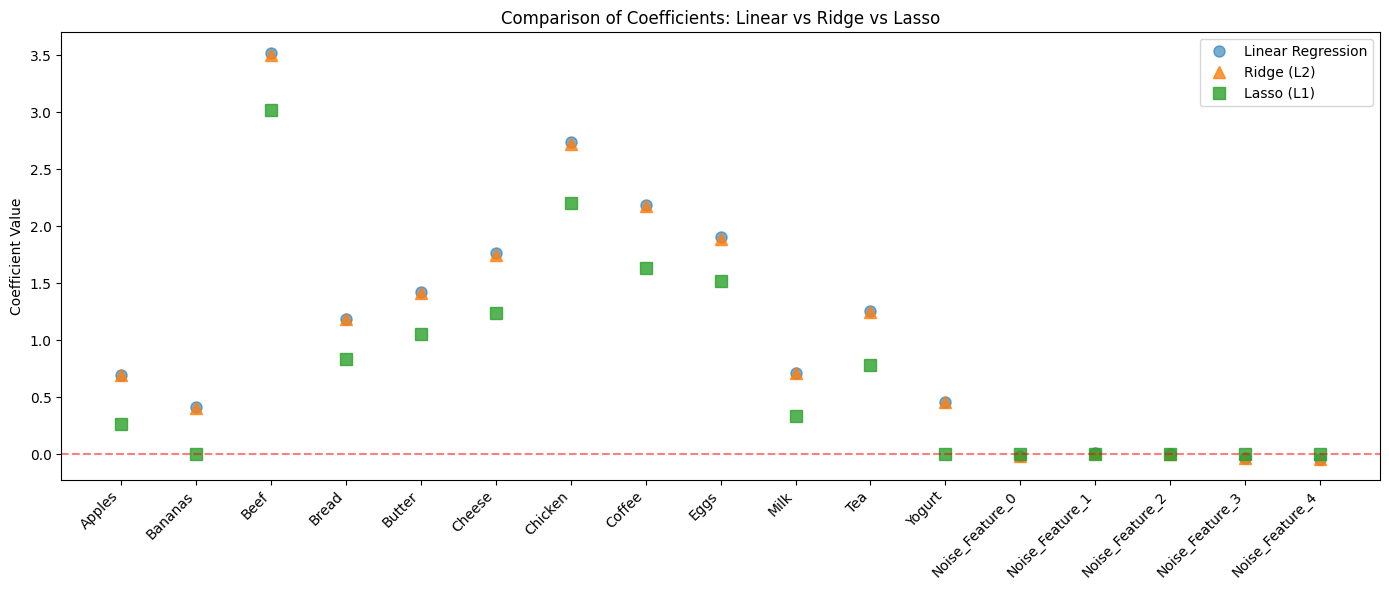

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')

def generate_grocery_data(num_transactions=1000):
    """
    Generates a synthetic grocery dataset.
    Assigns prices to formulate a regression problem for Ridge/Lasso.
    """

    np.random.seed(42)

    items = {
        'Bread': 2.50, 'Butter': 3.00, 'Milk': 1.50, 'Eggs': 4.00,
        'Apples': 2.00, 'Bananas': 1.00, 'Cheese': 5.00, 'Yogurt': 1.20,
        'Coffee': 6.00, 'Tea': 3.50, 'Chicken': 8.00, 'Beef': 10.00
    }

    transactions = []
    total_spends = []

    for _ in range(num_transactions):
        basket = []
        spend = 0.0

        # Inject association patterns
        if np.random.rand() > 0.5:
            basket.append('Bread')
            spend += items['Bread']
            if np.random.rand() > 0.3:
                basket.append('Butter')
                spend += items['Butter']

        if np.random.rand() > 0.4:
            basket.append('Milk')
            spend += items['Milk']
            if np.random.rand() > 0.2:
                basket.append('Eggs')
                spend += items['Eggs']

        # Add random other items
        for item, price in items.items():
            if item not in basket and np.random.rand() > 0.85:
                basket.append(item)
                spend += price

        # Add some random noise to spend
        spend += np.random.normal(0, 1.5)
        spend = max(0.5, spend)

        if len(basket) == 0:
            basket.append('Bananas')
            spend += items['Bananas']

        transactions.append(basket)
        total_spends.append(spend)

    return transactions, total_spends

def shrinkage_methods_demo(df_encoded, total_spends):
    print("\n" + "="*50)
    print(" PROJECT 1: SHRINKAGE METHODS (RIDGE & LASSO)")
    print("="*50)

    # Regression problem: Predict Total Spend based on the items in the basket.
    np.random.seed(42)
    num_noise_features = 5
    for i in range(num_noise_features):
        df_encoded[f'Noise_Feature_{i}'] = np.random.rand(len(df_encoded))

    X = df_encoded.astype(float)
    y = np.array(total_spends)

    # 1. Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Scale Features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    # 3. Train Models
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    lr_pred = lr.predict(X_test_scaled)

    ridge = Ridge(alpha=10.0)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)

    lasso = Lasso(alpha=0.5)
    lasso.fit(X_train_scaled, y_train)
    lasso_pred = lasso.predict(X_test_scaled)

    # 4. Evaluate Models
    print("\nModel Performance (R^2 Score):")
    print(f"Linear Regression: {r2_score(y_test, lr_pred):.4f}")
    print(f"Ridge Regression:  {r2_score(y_test, ridge_pred):.4f}")
    print(f"Lasso Regression:  {r2_score(y_test, lasso_pred):.4f}")

    # 5. Analyze Coefficients
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'LR_Coef': lr.coef_,
        'Ridge_Coef': ridge.coef_,
        'Lasso_Coef': lasso.coef_
    })

    print("\nFeature Coefficients Comparison:")
    display_cols = list(X.columns[:3]) + list(X.columns[-3:])
    print(coef_df[coef_df['Feature'].isin(display_cols)].to_string(index=False))

    print("\nNotice how Lasso pushes the coefficients of noise features completely to 0.0,")
    print("while Ridge just shrinks them to be very small.")

    # 6. Plotting
    plt.figure(figsize=(14, 6))
    plt.plot(coef_df['Feature'], coef_df['LR_Coef'], 'o', label='Linear Regression', alpha=0.6, markersize=8)
    plt.plot(coef_df['Feature'], coef_df['Ridge_Coef'], '^', label='Ridge (L2)', alpha=0.8, markersize=8)
    plt.plot(coef_df['Feature'], coef_df['Lasso_Coef'], 's', label='Lasso (L1)', alpha=0.8, markersize=8)

    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Coefficient Value')
    plt.title('Comparison of Coefficients: Linear vs Ridge vs Lasso')
    plt.legend()
    plt.tight_layout()
    plt.savefig('project1_shrinkage_coefficients.png')
    print("\nPlot saved as 'project1_shrinkage_coefficients.png'")

if __name__ == "__main__":
    print("Generating Synthetic Grocery Dataset...")
    transactions, total_spends = generate_grocery_data(num_transactions=2000)

    # Encode transactions to create features for regression
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

    shrinkage_methods_demo(df_encoded, total_spends)
    print("\nProject 1 execution complete!")

In [2]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

def generate_grocery_data(num_transactions=1000):
    """
    Generates a synthetic grocery dataset for Market Basket Analysis.
    """
    np.random.seed(42)

    items = ['Bread', 'Butter', 'Milk', 'Eggs', 'Apples', 'Bananas',
             'Cheese', 'Yogurt', 'Coffee', 'Tea', 'Chicken', 'Beef']

    transactions = []

    for _ in range(num_transactions):
        basket = []

        # Inject association patterns
        if np.random.rand() > 0.5:
            basket.append('Bread')
            if np.random.rand() > 0.3:
                basket.append('Butter')

        if np.random.rand() > 0.4:
            basket.append('Milk')
            if np.random.rand() > 0.2:
                basket.append('Eggs')

        # Add random other items
        for item in items:
            if item not in basket and np.random.rand() > 0.85:
                basket.append(item)

        if len(basket) == 0:
            basket.append('Bananas')

        transactions.append(basket)

    return transactions

def market_basket_analysis(transactions):
    print("\n" + "="*50)
    print(" PROJECT 2: MARKET BASKET ANALYSIS (APRIORI)")
    print("="*50)

    # One-hot encoding the transactions
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df = pd.DataFrame(te_ary, columns=te.columns_)

    print(f"Dataset shape after one-hot encoding: {df.shape}")

    # 1. Apply Apriori
    frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

    print("\nTop 5 Frequent Itemsets:")
    print(frequent_itemsets.sort_values('support', ascending=False).head())

    # 2. Extract Association Rules
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    print("\nTop 5 Association Rules (sorted by lift):")
    top_rules = rules.sort_values('lift', ascending=False).head()
    print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

    return df

if __name__ == "__main__":
    print("Generating Synthetic Grocery Dataset...")
    transactions = generate_grocery_data(num_transactions=2000)

    df_encoded = market_basket_analysis(transactions)
    print("\nProject 2 execution complete!")

Generating Synthetic Grocery Dataset...

 PROJECT 2: MARKET BASKET ANALYSIS (APRIORI)
Dataset shape after one-hot encoding: (2000, 12)

Top 5 Frequent Itemsets:
    support      itemsets  length
9    0.6740        (Milk)       1
3    0.5735       (Bread)       1
8    0.5680        (Eggs)       1
21   0.5250  (Eggs, Milk)       2
4    0.4460      (Butter)       1

Top 5 Association Rules (sorted by lift):
       antecedents     consequents  support  confidence      lift
25   (Bread, Milk)  (Butter, Eggs)   0.1955    0.509115  2.082268
26  (Butter, Eggs)   (Bread, Milk)   0.1955    0.799591  2.082268
24   (Bread, Eggs)  (Butter, Milk)   0.1955    0.615748  2.018846
27  (Butter, Milk)   (Bread, Eggs)   0.1955    0.640984  2.018846
11        (Butter)   (Bread, Milk)   0.2645    0.593049  1.544399

Project 2 execution complete!
